In [ ]:
# install packages
!pip install pandas numpy matplotlib seaborn fastapi nest-asyncio pyngrok uvicorn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.4 MB/s eta 0:00:00


In [ ]:
# import necessary pacakages
import pandas as pd
import numpy as np

In [ ]:
data_df = pd.DataFrame()
sample_size = 5_000_000

In [ ]:
data_df['transaction_id'] = list(range(1, sample_size))

# trans type
trans_type = [1, 2] # {1: 'DEBIT', '2':Credit}
trans_type_prob = [0.7, 0.3]
data_df['tran_type_id'] = np.random.choice(trans_type, size=sample_size-1, p=trans_type_prob)

# transaction amount
min_amount = 0
max_amount = 1_000_000
data_df['transaction_amount'] = np.random.uniform(low=min_amount, high=max_amount, size=sample_size-1)

# trans date
start_date = pd.to_datetime('2025-01-01 00:00:00')
end_date = pd.to_datetime('2025-05-31 23:59:59')
random_integers = np.random.randint(0, int((end_date - start_date).total_seconds()), sample_size-1)
data_df['tran_date'] = start_date + pd.to_timedelta(random_integers, unit='s')

# status_type_id
status_options = [1, 2] # 1: success, 2: failed
trans_type_prob = [0.98, 0.02]
data_df['status_type_id'] = np.random.choice(trans_type, size=sample_size-1, p=trans_type_prob)

# from acc id
acc_id_min_val = 1000
acc_id_max_val = 5000
data_df['from_acc_id'] = np.random.randint(low=acc_id_min_val, high=acc_id_max_val, size=sample_size-1)


# to_acc_id
to_id_min_val = 1000
to_id_max_val = 5000
data_df['to_acc_id'] = np.random.randint(low=to_id_min_val, high=to_id_max_val, size=sample_size-1)

# is_fraudulent
is_fraudulent_flag = [1, 0] # 1: yes, 2: no
is_fraudulent_prob = [0.4, 0.6]
data_df['is_fraudulent'] = np.random.choice(is_fraudulent_flag, size=sample_size-1, p=is_fraudulent_prob)


In [ ]:
data_df.shape

(4999999, 8)

In [ ]:
data_df.head()

,transaction_id,tran_type_id,transaction_amount,tran_date,status_type_id,from_acc_id,to_acc_id,is_fraudulent
0,1,1,863420.277729,2025-04-21 21:41:25,1,4529,2621,0
1,2,2,178013.178857,2025-03-13 05:09:58,1,4151,2343,1
2,3,1,256859.751292,2025-02-18 16:35:24,1,2775,1797,1
3,4,1,352894.102232,2025-04-16 04:33:58,1,2026,4546,1
4,5,1,309195.660677,2025-02-01 04:18:17,1,1929,4383,0


In [ ]:
data_df.isnull().sum()

,0
transaction_id,0
tran_type_id,0
transaction_amount,0
tran_date,0
status_type_id,0
from_acc_id,0
to_acc_id,0
is_fraudulent,0


In [ ]:
data_df.is_fraudulent.value_counts(normalize=True)

,proportion
is_fraudulent,
0,0.59987
1,0.40013


In [ ]:
data_df.tran_type_id.value_counts(normalize=True)

,proportion
tran_type_id,
1,0.699886
2,0.300114


In [ ]:
data_df.status_type_id.value_counts(normalize=True)

,proportion
status_type_id,
1,0.979942
2,0.020058


In [ ]:
data_df.sort_values('tran_date').to_parquet('bank_fradulent.parquet', index=False)

In [ ]:
# feature generation

Explanation of Features:

Log Transformation: Converts transaction_amount into a logarithmic scale to manage skewness and outlier effects.

Date Features: Extracts year, month, day, day of the week, and hour from tran_date to capture temporal patterns.

Interaction Features: Uses interactions between features, like multiplying transaction_amount by status_type_id, to capture combined effects.

Aggregated Features: Calculates aggregated metrics, like total transactions and average transaction amounts per account (from_acc_id).

One-Hot Encoding: Encodes categorical variables tran_type_ID and status_type_id using dummy variables.

Fraud Ratio: Computes the ratio of fraudulent transactions for each from_acc_id to capture account-level fraud tendencies.

These are just starting points. You can expand feature generation depending on the richness of your data and specific requirements, always keeping model interpretability and complexity in mind.

In [ ]:
data_df = pd.read_parquet('/content/bank_fradulent.parquet')

In [ ]:
# Feature Engineering
feat_df = data_df.copy()

# 1. Transaction Amount Logarithm
feat_df['log_transaction_amount'] = np.log(feat_df['transaction_amount'] + 1)

# 2. Transaction Date Features (Year, Month, Day of Week, Hour)
feat_df['tran_date'] = pd.to_datetime(feat_df['tran_date'])
feat_df['trans_year'] = feat_df['tran_date'].dt.year
feat_df['trans_month'] = feat_df['tran_date'].dt.month
feat_df['trans_day'] = feat_df['tran_date'].dt.day
feat_df['trans_day_of_week'] = feat_df['tran_date'].dt.dayofweek
feat_df['trans_hour'] = feat_df['tran_date'].dt.hour

# 3. Interaction Features
feat_df['amount_status_interaction'] = feat_df['transaction_amount'] * feat_df['status_type_id']

# 4. Aggregated Features
# Total Transactions and Average Amount for each 'from_acc_id'
total_transactions_per_account = feat_df.groupby('from_acc_id').size().rename('total_transactions')
average_amount_per_account = feat_df.groupby('from_acc_id')['transaction_amount'].mean().rename('avg_amount_per_account')

feat_df = feat_df.join(total_transactions_per_account, on='from_acc_id')
feat_df = feat_df.join(average_amount_per_account, on='from_acc_id')

# 5. Encode Categorical Features
# Simple One Hot Encoding for transactional Type and Status
# feat_df = pd.get_dummies(feat_df, columns=['tran_type_id', 'status_type_id'], prefix=['type', 'status'], drop_first=True)

# 6. Fraud Ratio of each from_acc_id
fraud_ratio = feat_df.groupby('from_acc_id')['is_fraudulent'].mean().rename('fraud_ratio')

feat_df = feat_df.join(fraud_ratio, on='from_acc_id')

In [ ]:
feat_df.to_parquet('features_feat_df.parquet', index=False)

# model building

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import pickle

# Assuming `df` is your DataFrame with features generated previously
feat_df = pd.read_parquet('/content/features_feat_df.parquet')

# Define features and target
skip_cols = ['transaction_id', 'transaction_amount', 'tran_date', 'from_acc_id',
       'to_acc_id', 'is_fraudulent']
X = feat_df.drop(columns=skip_cols)
y = feat_df['is_fraudulent']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# create standard sclaer
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# save stanard sclare model
with open('standard_scaler.pkl', 'wb') as file:
    pickle.dump(sc, file)

# Create an XGBoost Classifier
xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'  # XGBoost's eval metric for binary classification
)

# Train the model
xgb_classifier.fit(X_train, y_train)

# Save using pickle
with open('xgb_model.pkl', 'wb') as file:
    pickle.dump(xgb_classifier, file)

# Make predictions
y_pred_train = xgb_classifier.predict(X_train)
y_pred_test = xgb_classifier.predict(X_test)

# Evaluate the model
print("Training Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:48:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training Accuracy: 0.5998566499641624
Test Accuracy: 0.599954

Classification Report:
               precision    recall  f1-score   support

           0       0.60      1.00      0.75    599957
           1       0.20      0.00      0.00    400043

    accuracy                           0.60   1000000
   macro avg       0.40      0.50      0.37   1000000
weighted avg       0.44      0.60      0.45   1000000



In [ ]:
set(y_pred_test)

{np.int64(0), np.int64(1)}

# feature importance

Feature importances:
fraud_ratio: 0.4385
avg_amount_per_account: 0.0628
trans_hour: 0.0584
status_type_id: 0.0580
trans_day: 0.0576
total_transactions: 0.0575
trans_day_of_week: 0.0559
amount_status_interaction: 0.0552
log_transaction_amount: 0.0533
tran_type_id: 0.0521
trans_month: 0.0507
trans_year: 0.0000


<Figure size 1200x800 with 0 Axes>

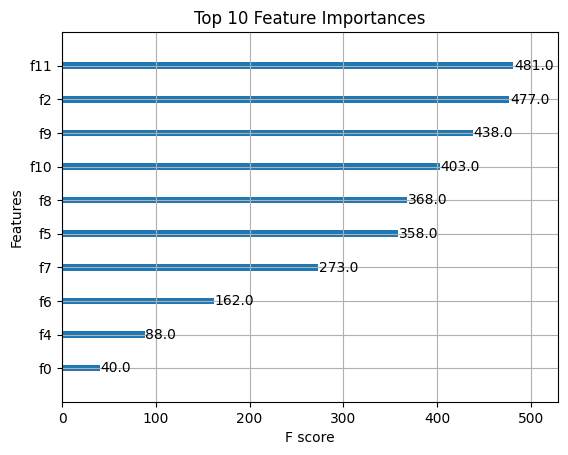

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Assuming xgb_classifier is your trained XGBoost model from previous steps

# Method 1: Extract feature importances as numbers (useful for reporting or further analysis)
importances = xgb_classifier.feature_importances_

# Print feature importances
feature_names = X.columns
importance_dict = dict(zip(feature_names, importances))
sorted_importance = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

print("Feature importances:")
for feature, score in sorted_importance:
    print(f"{feature}: {score:.4f}")

# Method 2: Visualize feature importances using matplotlib plot (bar chart style)
plt.figure(figsize=(12, 8))
xgb.plot_importance(xgb_classifier, max_num_features=10, importance_type='weight')  # Choose importance_type: "weight", "gain", "cover", etc.
plt.title('Top 10 Feature Importances')
plt.show()

# scoring using fast-api

In [ ]:
from pydantic import BaseModel, validator
from typing import List
from datetime import datetime, date, time
import pandas as pd
import numpy as np
# from fastapi import FastAPI, HTTPException
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Define the Pydantic model for the request body
class TransData(BaseModel):
    transaction_id: int
    tran_type_id: int
    transaction_amount: int
    tran_date: datetime
    status_type_id: int
    from_acc_id: int
    to_acc_id: int

    @validator('tran_type_id')
    def validate_tran_type_id(cls, value):
      trans_type_allowed_values = [1, 2]
      if value not in trans_type_allowed_values:
          raise ValueError(f"must be one of: {trans_type_allowed_values}")
      return value

    @validator('status_type_id')
    def validate_status_type_id(cls, value):
      status_type_allowed_values = [1, 2]
      if value not in status_type_allowed_values:
          raise ValueError(f"must be one of: {status_type_allowed_values}")
      return value


<ipython-input-23-90782a52ad27>:20: PydanticDeprecatedSince20: Pydantic V1 style `@validator` validators are deprecated. You should migrate to Pydantic V2 style `@field_validator` validators, see the migration guide for more details. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  @validator('trans_type_ID')
<ipython-input-23-90782a52ad27>:27: PydanticDeprecatedSince20: Pydantic V1 style `@validator` validators are deprecated. You should migrate to Pydantic V2 style `@field_validator` validators, see the migration guide for more details. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  @validator('status_type_id')


In [ ]:
# feature generate

def get_histoical_trans_df(from_acc_id):
  # sql code to connect and get data
  return pd.DataFrame()

def generate_agg_feat_df(from_acc_id):
  hist_df = get_histoical_trans_df(from_acc_id)
  if not hist_df.empty:
    fraud_ratio = hist_df.groupby('from_acc_id')['is_fraudulent'].mean().rename('fraud_ratio').iloc[0]
    total_transactions_per_account = hist_df.groupby('from_acc_id').size().rename('total_transactions').iloc[0]
    average_amount_per_account = hist_df.groupby('from_acc_id')['transaction_amount'].mean().rename('avg_amount_per_account').iloc[0]
  else:
    fraud_ratio = 0
    total_transactions_per_account = 0
    average_amount_per_account = 0

  return fraud_ratio, total_transactions_per_account, average_amount_per_account

def generate_features(df):

  feat_df = df.copy()

  # 0. get aggregation for from_acc_id
  fraud_ratio, total_transactions_per_account, average_amount_per_account = generate_agg_feat_df(feat_df['from_acc_id'].iloc[0])

  # 1. Transaction Amount Logarithm
  feat_df['log_transaction_amount'] = np.log(feat_df['transaction_amount'] + 1)

  # 2. Transaction Date Features (Year, Month, Day of Week, Hour)
  feat_df['tran_date'] = pd.to_datetime(feat_df['tran_date'])
  feat_df['trans_year'] = feat_df['tran_date'].dt.year
  feat_df['trans_month'] = feat_df['tran_date'].dt.month
  feat_df['trans_day'] = feat_df['tran_date'].dt.day
  feat_df['trans_day_of_week'] = feat_df['tran_date'].dt.dayofweek
  feat_df['trans_hour'] = feat_df['tran_date'].dt.hour

  # 3. Interaction Features
  feat_df['amount_status_interaction'] = feat_df['transaction_amount'] * feat_df['status_type_id']

  # 4. Aggregated Features
  # Total Transactions and Average Amount for each 'from_acc_id'
  feat_df["total_transactions"] = total_transactions_per_account
  feat_df["avg_amount_per_account"] = average_amount_per_account

  # 5. Encode Categorical Features
  # Simple One Hot Encoding for transactional Type and Status
  # feat_df = pd.get_dummies(feat_df, columns=['tran_type_id', 'status_type_id'], prefix=['type', 'status'], drop_first=True)

  # 6. Fraud Ratio of each from_acc_id
  feat_df["fraud_ratio"] = fraud_ratio

  return feat_df


In [ ]:
def predict_fraud(trans_data):

  skip_cols = ['transaction_id', 'transaction_amount', 'tran_date', 'from_acc_id', 'to_acc_id',]

  # converting dictionary to dataframe
  trans_df = pd.DataFrame(trans_data, index=[0])

  # generate features
  feat_df = generate_features(trans_df)
  feat_df.drop(columns=skip_cols, axis=1, inplace=True)

  # scale features
  feature_cols = list(feat_df.columns)
  scaled_feat_df = sc_model.transform(feat_df)

  # Transform features to suitable input format
  # dmatrix = xgb.DMatrix(np.float32(scaled_feat_df), feature_names=feature_cols)

  # Predict using the model
  prediction = xgboost_model.predict(scaled_feat_df)

  # Process prediction for response
  print(prediction)
  is_fraudulent = (prediction > model_threshold).astype(int)

  return is_fraudulent



In [ ]:
# test_trans_data = {'transaction_id': 465858,
#  'tran_type_id': 1,
#  'transaction_amount': 85951,
#  'tran_date': '2025-01-01 00:00:01',
#  'status_type_id': 1,
#  'from_acc_id': 1840,
#  'to_acc_id': 3094,
#  }

# # converting dictionary to dataframe
# test_trans_data = pd.DataFrame(test_trans_data, index=[0])

# # t_df = generate_features(test_trans_data)

# # generate features
# predict_fraud(test_trans_data)

Index(['transaction_id', 'trans_type_ID', 'transaction_amount', 'trans_date',
       'status_type_id', 'from_acc_id', 'to_acc_id', 'log_transaction_amount',
       'trans_year', 'trans_month', 'trans_day', 'trans_day_of_week',
       'trans_hour', 'amount_status_interaction', 'total_transactions',
       'avg_amount_per_account', 'fraud_ratio'],
      dtype='object')
Index(['trans_type_ID', 'status_type_id', 'log_transaction_amount',
       'trans_year', 'trans_month', 'trans_day', 'trans_day_of_week',
       'trans_hour', 'amount_status_interaction', 'total_transactions',
       'avg_amount_per_account', 'fraud_ratio'],
      dtype='object')
[0]


array([0])

In [ ]:

# Initialize FastAPI app
app = FastAPI()

# Load your standard scalre
with open('/content/xgb_model.pkl', 'rb') as file:
    xgboost_model = pickle.load(file)

# Load your pre-trained model
with open('/content/standard_scaler.pkl', 'rb') as file:
    sc_model = pickle.load(file)

model_threshold = 0.6

# Define POST endpoint
@app.post("/transaction/validate/")
async def validate_transaction(trans: TransData):
  is_fraudulent = predict_fraud(trans.dict())
  return {"is_fraudulent": bool(is_fraudulent)}


NameError: name 'FastAPI' is not defined

In [ ]:
import nest_asyncio
from pyngrok import ngrok
import uvicorn

ngrok_tunnel = ngrok.connect(8000)
print('Public URL:', ngrok_tunnel.public_url)
nest_asyncio.apply()
uvicorn.run(app, port=8000)


ERROR:pyngrok.process.ngrok:t=2025-05-31T12:31:46+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2025-05-31T12:31:46+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2025-05-31T12:31:46+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [ ]:
feat_df

,transaction_id,trans_type_ID,transaction_amount,trans_date,status_type_id,from_acc_id,to_acc_id,is_fradulent,log_transaction_amount,trans_year,trans_month,trans_day,trans_day_of_week,trans_hour,amount_status_interaction,total_transactions,avg_amount_per_account,fraud_ratio
0,1218663,2,6491.041835,2025-01-01 00:00:02,1,4879,2134,0,8.778332,2025,1,1,2,0,6491.041835,1235,497170.394828,0.421053
1,4854847,1,268112.725060,2025-01-01 00:00:04,2,1892,3888,1,12.499167,2025,1,1,2,0,536225.450119,1273,499382.957932,0.419482
2,1360327,1,496267.810616,2025-01-01 00:00:10,1,3402,2879,1,13.114873,2025,1,1,2,0,496267.810616,1201,497829.302406,0.398834
3,3247888,1,336468.171808,2025-01-01 00:00:11,1,3530,4904,1,12.726262,2025,1,1,2,0,336468.171808,1246,502271.741978,0.418138
4,3575057,1,650383.374696,2025-01-01 00:00:11,1,1889,1886,0,13.385319,2025,1,1,2,0,650383.374696,1282,502107.423116,0.397816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999994,314198,1,499380.525385,2025-05-31 23:59:50,1,2618,2953,1,13.121126,2025,5,31,5,23,499380.525385,1309,504117.825341,0.377387
4999995,2444615,1,774213.101446,2025-05-31 23:59:50,1,2949,1289,0,13.559604,2025,5,31,5,23,774213.101446,1214,497079.478678,0.397858
4999996,4104088,2,908343.838660,2025-05-31 23:59:51,1,4049,4105,1,13.719379,2025,5,31,5,23,908343.838660,1278,493268.866117,0.420970
4999997,675208,1,799954.723894,2025-05-31 23:59:52,1,3222,1676,0,13.592312,2025,5,31,5,23,799954.723894,1273,510964.456796,0.417910


In [ ]:
q_df = pd.read_parquet('/content/features_feat_df.parquet')


,transaction_id,trans_type_ID,transaction_amount,trans_date,status_type_id,from_acc_id,to_acc_id,is_fradulent,log_transaction_amount,trans_year,trans_month,trans_day,trans_day_of_week,trans_hour,amount_status_interaction,total_transactions,avg_amount_per_account,fraud_ratio
0,3994885,1,74966.665779,2025-01-01 00:00:05,1,2819,2474,1,11.224812,2025,1,1,2,0,74966.665779,1215,494015.065196,0.384362
1,3076992,1,215847.706622,2025-01-01 00:00:06,1,4360,4391,0,12.282333,2025,1,1,2,0,215847.706622,1217,500828.979689,0.411668
2,4114488,2,95880.553269,2025-01-01 00:00:08,1,3622,4142,0,11.470869,2025,1,1,2,0,95880.553269,1233,499867.992638,0.377129
3,897007,2,415866.375962,2025-01-01 00:00:11,1,1210,2801,1,12.938122,2025,1,1,2,0,415866.375962,1221,498369.720703,0.413595
4,3917344,1,882819.871645,2025-01-01 00:00:16,1,3114,3857,0,13.690878,2025,1,1,2,0,882819.871645,1250,512546.872723,0.416000


In [ ]:
t_df

,transaction_id,trans_type_ID,transaction_amount,trans_date,status_type_id,from_acc_id,to_acc_id,log_transaction_amount,trans_year,trans_month,trans_day,trans_day_of_week,trans_hour,amount_status_interaction,total_transactions,avg_amount_per_account,fraud_ratio
0,465858,1,85951,2025-01-01 00:00:01,1,1840,3094,11.361544,2025,1,1,2,0,85951,0,0,0


In [ ]:
set(t_df.columns) - set(q_df.columns)

set()

In [ ]:
 set(q_df.columns) -set(t_df.columns)

{'is_fradulent'}

In [ ]:
y_test_pred

NameError: name 'y_test_pred' is not defined

KeyError: "[('transaction_id', 'transaction_amount', 'trans_date', 'from_acc_id', 'to_acc_id', 'is_fradulent', 'trans_type_ID', 'status_type_id')] not found in axis"

In [ ]:
q_df.drop([skip_cols])

KeyError: "[('transaction_id', 'transaction_amount', 'trans_date', 'from_acc_id', 'to_acc_id', 'is_fradulent')] not found in axis"

In [ ]:
skip_cols = ['transaction_id',
 'transaction_amount',
 'tran_date',
 'from_acc_id',
 'to_acc_id',
 'is_fraudulent']

set(xgb_classifier.predict(sc.transform(q_df.drop(skip_cols, axis=1))))

{np.int64(0), np.int64(1)}